In [4]:
import os
import time
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.prune as prune
import torch_pruning as tp

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

warnings.filterwarnings("ignore")

LOG_DIR = "logs"
os.makedirs(LOG_DIR, exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Log dir: {os.path.abspath(LOG_DIR)}")

Device: cuda
Log dir: /home/user/projects/Quantization-and-Pruning/pruning/logs


In [ ]:
class LeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.bn1   = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.bn2   = nn.BatchNorm2d(16)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [22]:
# TRAIN_SUBSET = None 
# TEST_SUBSET  = None  

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST("./data", train=False, download=True, transform=transform)

# if TRAIN_SUBSET:
#     train_dataset = Subset(train_dataset, range(TRAIN_SUBSET))
# if TEST_SUBSET:
#     test_dataset = Subset(test_dataset, range(TEST_SUBSET))

train_loader = DataLoader(train_dataset, batch_size=64,  shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 60000 | Test: 10000


In [23]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = F.cross_entropy(out, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.size(0)
        correct += out.argmax(1).eq(target).sum().item()
        total += data.size(0)
    return total_loss / total, 100.0 * correct / total

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        out = model(data)
        loss = F.cross_entropy(out, target, reduction="sum")
        total_loss += loss.item()
        correct += out.argmax(1).eq(target).sum().item()
        total += data.size(0)
    return 100.0 * correct / total, total_loss / total

@torch.no_grad()
def measure_inference_ms(model, loader, device, n_batches=10):
    model.eval()
    times = []
    for i, (data, _) in enumerate(loader):
        if i >= n_batches:
            break
        data = data.to(device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model(data)
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000.0)
    return float(np.mean(times)) if times else float("nan")

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_mb(model):
    return count_params(model) * 4 / (1024 ** 2)

In [24]:
NUM_EPOCHS = 3
LR = 1e-3

base_model = LeNet().to(device)
optimizer  = torch.optim.Adam(base_model.parameters(), lr=LR)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(base_model, train_loader, optimizer, device)
    te_acc, te_loss = evaluate(base_model, test_loader, device)
    print(f"Epoch {epoch}: train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}%  "
          f"test_loss={te_loss:.4f} test_acc={te_acc:.2f}%")

base_state = copy.deepcopy(base_model.state_dict())
# torch.save(base_state, os.path.join(LOG_DIR, "base_model.pth"))

base_acc, _  = evaluate(base_model, test_loader, device)
base_time    = measure_inference_ms(base_model, test_loader, device)
base_params  = count_params(base_model)
base_size    = model_size_mb(base_model)

print(f"\nBaseline: acc={base_acc:.2f}%  params={base_params:,}  "
      f"size={base_size:.4f} MB  inf={base_time:.3f} ms")

pd.DataFrame([{
    "strategy": "baseline", "ratio": 0.0,
    "accuracy": base_acc, "loss": np.nan,
    "params": base_params, "size_mb": base_size,
    "inference_ms": base_time, "prune_time_s": 0.0,
}]).to_csv(os.path.join(LOG_DIR, "baseline.csv"), index=False)

Epoch 1: train_loss=0.1764 train_acc=95.02%  test_loss=0.0666 test_acc=97.81%
Epoch 2: train_loss=0.0554 train_acc=98.30%  test_loss=0.0517 test_acc=98.33%
Epoch 3: train_loss=0.0440 train_acc=98.68%  test_loss=0.0392 test_acc=98.71%

Baseline: acc=98.71%  params=44,470  size=0.1696 MB  inf=0.487 ms


## Structured pruning

In [26]:
example_inputs = torch.randn(1, 1, 28, 28, device=device)

In [27]:
def _prune_all_weights(model, method, ratio):
    params = [(m, "weight") for m in model.modules()
              if isinstance(m, (nn.Conv2d, nn.Linear))]
    prune.global_unstructured(params, pruning_method=method, amount=ratio)
    for m, name in params:
        prune.remove(m, name)
    return model

In [28]:
STRATEGIES = {
    "unstructured_l1":      lambda m, r: _prune_all_weights(m, prune.L1Unstructured, r),
    "unstructured_random":  lambda m, r: _prune_all_weights(m, prune.RandomUnstructured, r),
}

## Run experiment

In [29]:
PRUNING_RATIOS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

In [30]:
all_results = []

for strategy_name, prune_fn in STRATEGIES.items():
    print(f"\n=== {strategy_name} ===")
    rows = []
    for ratio in PRUNING_RATIOS:
        model = LeNet().to(device)
        model.load_state_dict(copy.deepcopy(base_state))

        t0 = time.perf_counter()
        try:
            model = prune_fn(model, ratio)
            ok, err = True, ""
        except Exception as e:
            ok, err = False, f"{type(e).__name__}: {e}"
        prune_time = time.perf_counter() - t0

        if ok:
            acc, loss = evaluate(model, test_loader, device)
            inf_ms    = measure_inference_ms(model, test_loader, device)
            n_params  = count_params(model)
            size_mb   = model_size_mb(model)
        else:
            acc = loss = inf_ms = n_params = size_mb = np.nan

        rows.append({
            "strategy": strategy_name, "ratio": ratio,
            "accuracy": acc, "loss": loss,
            "params": n_params, "size_mb": size_mb,
            "inference_ms": inf_ms, "prune_time_s": prune_time,
            "error": err,
        })
        status = f"acc={acc:.2f}%  params={n_params:,}  size={size_mb:.3f}MB  inf={inf_ms:.3f}ms" \
                 if ok else f"FAILED ({err})"
        print(f"  ratio={ratio:.2f}  {status}")

    pd.DataFrame(rows).to_csv(os.path.join(LOG_DIR, f"{strategy_name}.csv"), index=False)
    all_results.append(pd.DataFrame(rows))

df_all = pd.concat(all_results, ignore_index=True)
df_all.to_csv(os.path.join(LOG_DIR, "all_strategies.csv"), index=False)
print(f"\n✓ Saved: {os.path.abspath(LOG_DIR)}/all_strategies.csv")


=== unstructured_l1 ===
  ratio=0.00  acc=98.71%  params=44,470  size=0.170MB  inf=2.416ms
  ratio=0.10  acc=98.73%  params=44,470  size=0.170MB  inf=1.672ms
  ratio=0.20  acc=98.63%  params=44,470  size=0.170MB  inf=1.423ms
  ratio=0.30  acc=98.57%  params=44,470  size=0.170MB  inf=3.064ms
  ratio=0.40  acc=98.66%  params=44,470  size=0.170MB  inf=1.483ms
  ratio=0.50  acc=98.21%  params=44,470  size=0.170MB  inf=1.387ms
  ratio=0.60  acc=98.44%  params=44,470  size=0.170MB  inf=3.070ms
  ratio=0.70  acc=97.66%  params=44,470  size=0.170MB  inf=1.821ms

=== unstructured_random ===
  ratio=0.00  acc=98.71%  params=44,470  size=0.170MB  inf=1.588ms
  ratio=0.10  acc=98.07%  params=44,470  size=0.170MB  inf=2.582ms
  ratio=0.20  acc=84.45%  params=44,470  size=0.170MB  inf=1.633ms
  ratio=0.30  acc=69.57%  params=44,470  size=0.170MB  inf=3.659ms
  ratio=0.40  acc=28.70%  params=44,470  size=0.170MB  inf=1.812ms
  ratio=0.50  acc=21.60%  params=44,470  size=0.170MB  inf=1.636ms
  ratio=

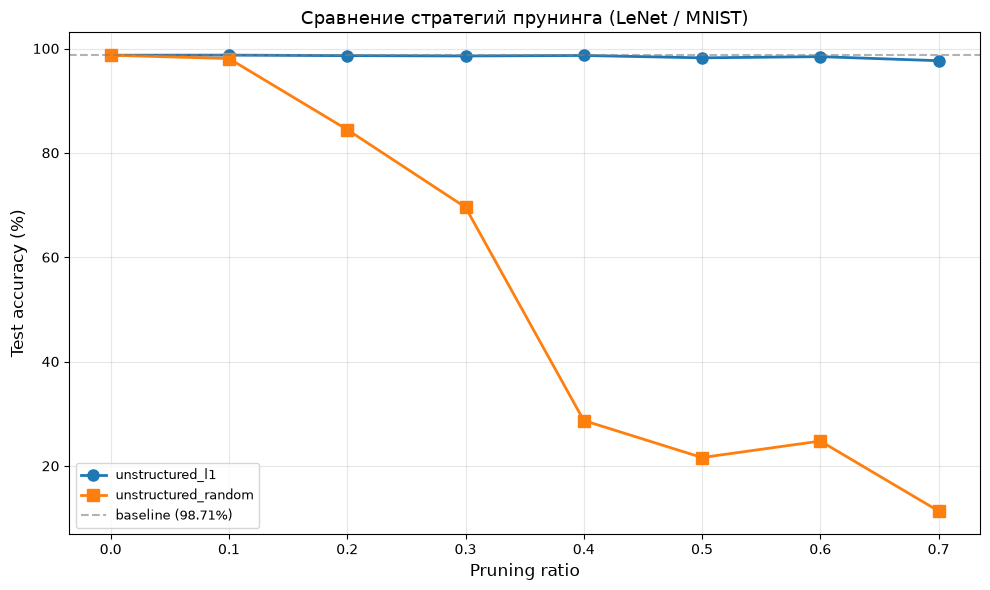

Saved: logs/accuracy_all_strategies_single.png


In [ ]:
df_plot   = df_all.dropna(subset=["accuracy"]).copy()
baseline  = pd.read_csv(os.path.join(LOG_DIR, "baseline.csv")).iloc[0]
strategies = list(df_plot["strategy"].unique())

cmap    = plt.cm.tab10
colors  = [cmap(i) for i in range(len(strategies))]
markers = ["o", "s", "^", "D", "v", "P", "*"][: len(strategies)]

fig, ax = plt.subplots(figsize=(10, 6))
for i, s in enumerate(strategies):
    sub = df_plot[df_plot["strategy"] == s].sort_values("ratio")
    ax.plot(sub["ratio"], sub["accuracy"],
            marker=markers[i], color=colors[i], label=s,
            linewidth=2, markersize=8)

ax.axhline(y=baseline["accuracy"], color="gray", ls="--", alpha=0.6,
           label=f"baseline ({baseline['accuracy']:.2f}%)")

ax.set_xlabel("Pruning ratio", fontsize=12)
ax.set_ylabel("Test accuracy (%)", fontsize=12)
ax.set_title("Сравнение стратегий прунинга (LeNet / MNIST)", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()